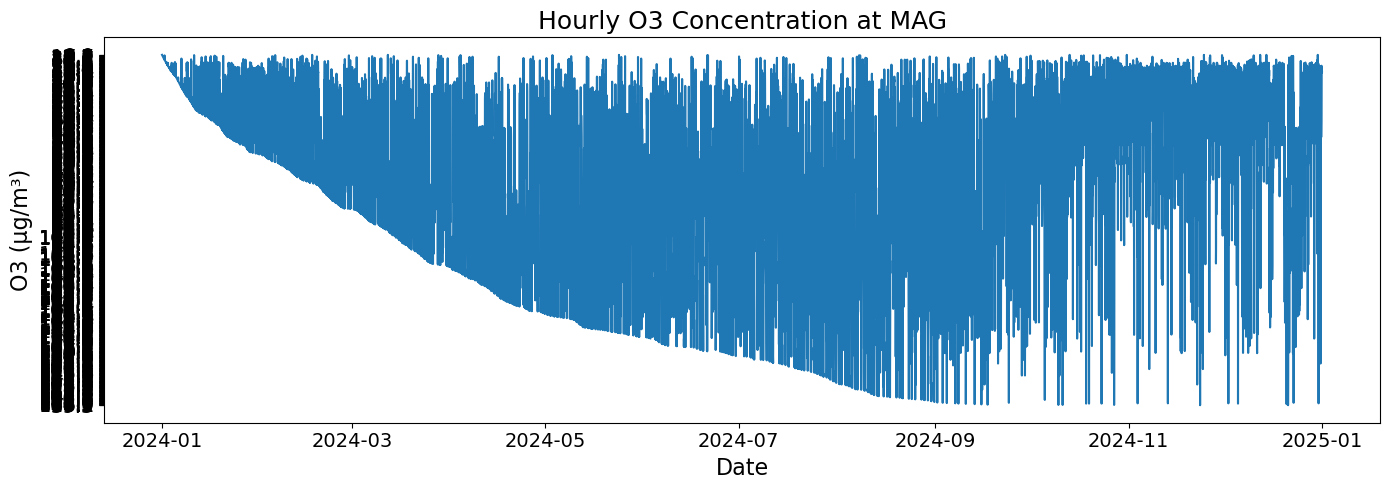

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

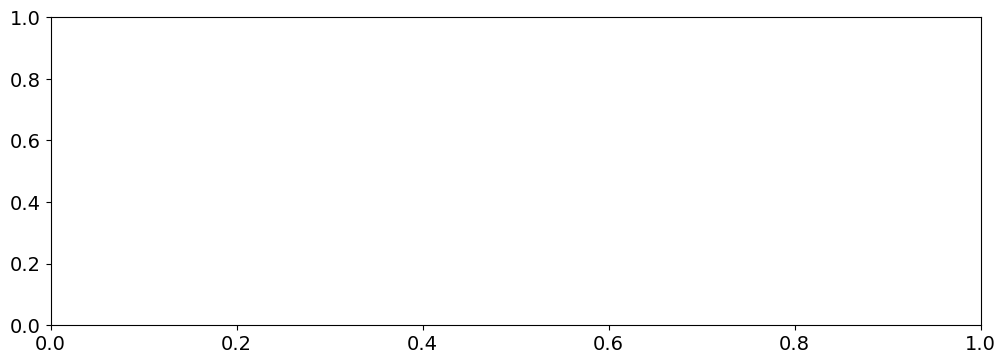

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter

plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.titlesize': 18
})

# Load and clean data
df = pd.read_csv('DATA.csv', sep=';', decimal=',', parse_dates=['TIME'], dayfirst=True)
df = df.rename(columns={'TIME': 'datetime'})
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

# Define function to plot all charts for one station
def plot_O3_analysis(station_code):
    col = f'O3{station_code}'
    df_station = df[['datetime', 'date', 'hour', 'day', 'month', col]].copy()
    df_station = df_station.rename(columns={col: 'O3'})
    df_station = df_station.dropna()

    # Time series: hourly
    plt.figure(figsize=(14, 5))
    sns.lineplot(data=df_station, x='datetime', y='O3')
    plt.title(f'Hourly O3 Concentration at {station_code}')
    plt.xlabel('Date')
    plt.ylabel('O3 (µg/m³)')
    plt.tight_layout()
    plt.show()

    # Density and ECDF
    plt.figure(figsize=(12, 4))
    sns.kdeplot(df_station['O3'], fill=True)
    plt.axvline(100, color='red', linestyle='--', label='Limit')
    plt.title(f'Probability Density of Hourly O3 at {station_code}')
    plt.xlabel('O3 (µg/m³)')
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    sns.ecdfplot(df_station['O3'])
    plt.axvline(100, color='red', linestyle='--', label='Limit')
    plt.title(f'ECDF of Hourly O3 at {station_code}')
    plt.xlabel('O3 (µg/m³)')
    plt.ylabel('Cumulative Probability')
    plt.tight_layout()
    plt.show()

    # Extreme hourly values > 100
    extreme_hourly = df_station[df_station['O3'] > 140]
    print(f"\nExtreme hourly O3 values at {station_code} (>140 µg/m³):\n", extreme_hourly)

    # Diurnal variation on those dates
    high_dates = extreme_hourly['date'].unique()
    highdays = df_station[df_station['date'].isin(high_dates)]
    number_of_highdays = len(highdays['date'].unique())

    if not highdays.empty:
        g = sns.FacetGrid(highdays, col='date', col_wrap=number_of_highdays, height=4)
        g.map_dataframe(sns.lineplot, x='hour', y='O3', marker='o')
        g.set_axis_labels("Hour of day", "O3 (µg/m³)")
        g.fig.suptitle(f'Diurnal O3 Variation on High Days at {station_code}', y=1.05)
        plt.tight_layout()
        plt.show()

        # Mean and trimmed mean
        print("\nMean daily O3 on high days:")
        print(highdays.groupby('date')['O3'].mean())

        print("\nTrimmed mean daily O3 (10% trim):")
        from scipy.stats import trim_mean
        print(highdays.groupby('date')['O3'].apply(lambda x: trim_mean(x, proportiontocut=0.1)))

    # Daily means
    daily = df_station.groupby('date')['O3'].mean().reset_index()
    daily['day'] = pd.to_datetime(daily['date']).dt.day
    daily['month'] = pd.to_datetime(daily['date']).dt.month

    # Time series of daily means
    g = sns.FacetGrid(daily, col='month', col_wrap=3, height=4)
    g.map_dataframe(sns.lineplot, x='day', y='O3', marker='o')
    g.set_axis_labels("Day", "Daily Mean O3 (µg/m³)")
    g.fig.suptitle(f'Daily O3 Means at {station_code}', y=1.05)
    plt.tight_layout()
    plt.show()

    # Density & ECDF of daily means
    plt.figure(figsize=(12, 4))
    sns.kdeplot(daily['O3'], fill=True)
    plt.axvline(x=50, linestyle='--', color='red')
    plt.title(f'Density of Daily Mean O3 at {station_code}')
    plt.xlabel('Daily Mean O3 (µg/m³)')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    sns.ecdfplot(daily['O3'])
    plt.axvline(x=50, linestyle='--', color='red')
    plt.title(f'ECDF of Daily Mean O3 at {station_code}')
    plt.xlabel('Daily Mean O3 (µg/m³)')
    plt.tight_layout()
    plt.show()

    # Days exceeding threshold
    exceeded = daily[daily['O3'] > 100]
    print(f"\nDays with daily mean O3 > 100 µg/m³ at {station_code}:\n", exceeded)

    exceed_hours = df_station[df_station['date'].isin(exceeded['date'])]
    number_of_exceed_hours = len(exceed_hours['date'].unique())
    if not exceed_hours.empty:
        g = sns.FacetGrid(exceed_hours, col='date', col_wrap=number_of_exceed_hours, height=4)
        g.map_dataframe(sns.lineplot, x='hour', y='O3', marker='o')
        g.set_axis_labels("Hour of day", "O3 (µg/m³)")
        g.set(ylim=(0, 100))
        g.fig.suptitle(f'Diurnal Patterns on O3 Exceedance Days at {station_code}', y=1.05)
        plt.tight_layout()
        plt.show()

# Run for both stations
plot_O3_analysis('MAG')
plot_O3_analysis('CHA')